# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

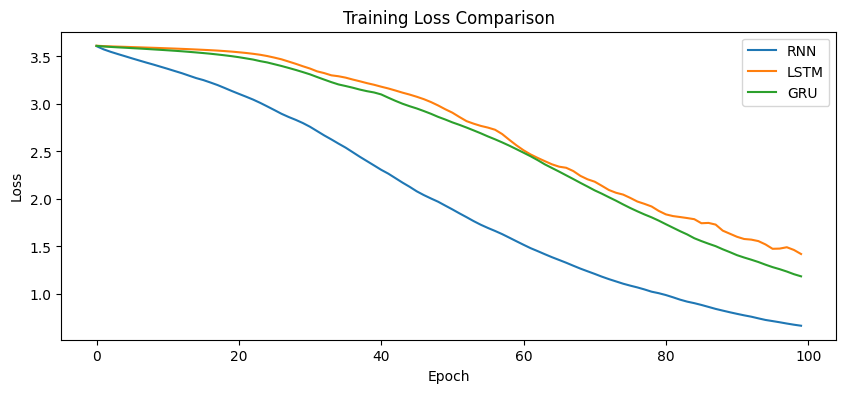

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is can generate meaningful sentences
GRU : deep learning models can generate meaningful meaningful


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

##Task1- Replace Corpus with Your Own Paragraph

In [16]:
my_corpus = '''
the sun rises in the east and sets in the west
stars appear in the sky at night
the moon reflects the light of the sun
clouds bring rain and rain brings life
nature is beautiful and full of wonders
birds fly high in the clear blue sky
'''

# Re-tokenize with the new corpus
tokenizer2 = Tokenizer()
tokenizer2.fit_on_texts([my_corpus])

total_words2 = len(tokenizer2.word_index) + 1
print("New Vocabulary size:", total_words2)
print("Words learned:", list(tokenizer2.word_index.keys()))

New Vocabulary size: 33
Words learned: ['the', 'in', 'and', 'sun', 'sky', 'of', 'rain', 'rises', 'east', 'sets', 'west', 'stars', 'appear', 'at', 'night', 'moon', 'reflects', 'light', 'clouds', 'bring', 'brings', 'life', 'nature', 'is', 'beautiful', 'full', 'wonders', 'birds', 'fly', 'high', 'clear', 'blue']


##Task 2 — Increase Embedding Dimension

Increasing the dimension of the embedding help model understand words better.

Changing Embeddign Dimension from 32 to 64

In [22]:
input_sequences2 = []
for line in my_corpus.strip().split('\n'):
    token_list = tokenizer2.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences2.append(n_gram_seq)

max_len2 = max(len(seq) for seq in input_sequences2)
input_sequences2 = pad_sequences(input_sequences2, maxlen=max_len2, padding='pre')

X2 = input_sequences2[:, :-1]
y2 = input_sequences2[:, -1]

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

# Training LSTM with Embedding dim = 64 (instead of 32)
lstm_embed64 = Sequential([
    Embedding(total_words2, 64, input_length=max_len2-1),  # 32 → 64
    LSTM(64),
    Dense(total_words2, activation='softmax')
])

lstm_embed64.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

history_embed64 = lstm_embed64.fit(X2, y2, epochs=100, verbose=0)
print("LSTM with Embedding=64 trained on your corpus")
print("Final Accuracy:", round(history_embed64.history['accuracy'][-1]*100, 2), "%")

X2 shape: (42, 10)
y2 shape: (42,)
LSTM with Embedding=64 trained on your corpus
Final Accuracy: 78.57 %


##Task 3 — Increase Epochs to 200

When model trains longer, it learns better(upto a limit)

LSTM trained for 200 epochs on your corpus
Loss at epoch 100 : 1.5413
Loss at epoch 200 : 0.5965


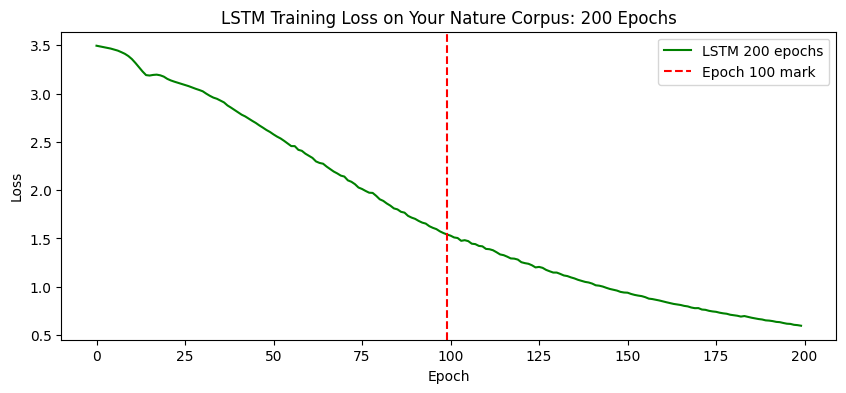

In [23]:
lstm_200epochs = Sequential([
    Embedding(total_words2, 32, input_length=max_len2-1),
    LSTM(64),
    Dense(total_words2, activation='softmax')
])

lstm_200epochs.compile(loss='sparse_categorical_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy'])

history_200 = lstm_200epochs.fit(X2, y2, epochs=200, verbose=0)
print("LSTM trained for 200 epochs on your corpus")
print(f"Loss at epoch 100 : {history_200.history['loss'][99]:.4f}")
print(f"Loss at epoch 200 : {history_200.history['loss'][199]:.4f}")

# Plot learning curve
plt.figure(figsize=(10, 4))
plt.plot(history_200.history['loss'], label='LSTM 200 epochs', color='green')
plt.axvline(x=99, color='red', linestyle='--', label='Epoch 100 mark')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training Loss on Your Nature Corpus: 200 Epochs")
plt.legend()
plt.show()

##Task 4 — Change Hidden Units from 64 → 128

RNN trained
LSTM trained
GRU trained
LSTM trained


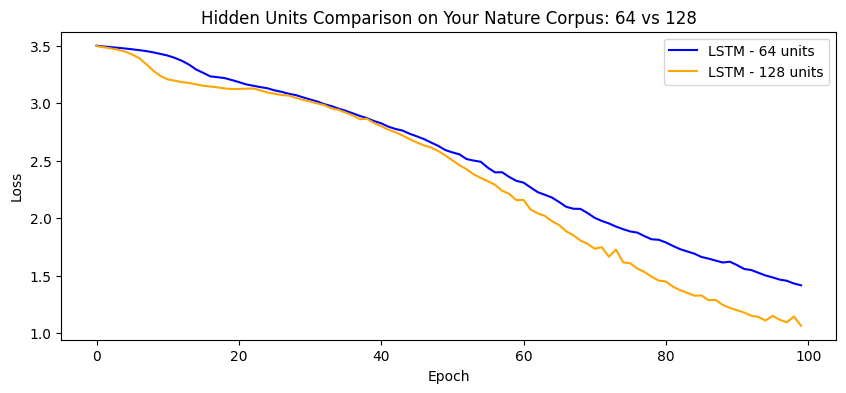

Final Accuracy (LSTM 64  units): 64.29 %
Final Accuracy (LSTM 128 units): 78.57 %


In [20]:
# Training 3 models (RNN, LSTM, GRU) with 64 units on your corpus

rnn_model2 = Sequential([
    Embedding(total_words2, 32, input_length=max_len2-1),
    SimpleRNN(64),
    Dense(total_words2, activation='softmax')
])
rnn_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history2 = rnn_model2.fit(X2, y2, epochs=100, verbose=0)
print("RNN trained")

lstm_model2 = Sequential([
    Embedding(total_words2, 32, input_length=max_len2-1),
    LSTM(64),
    Dense(total_words2, activation='softmax')
])
lstm_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history2 = lstm_model2.fit(X2, y2, epochs=100, verbose=0)
print("LSTM trained")

gru_model2 = Sequential([
    Embedding(total_words2, 32, input_length=max_len2-1),
    GRU(64),
    Dense(total_words2, activation='softmax')
])
gru_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_history2 = gru_model2.fit(X2, y2, epochs=100, verbose=0)
print("GRU trained")

# Now train LSTM with 128 units for comparison
lstm_128units = Sequential([
    Embedding(total_words2, 32, input_length=max_len2-1),
    LSTM(128),
    Dense(total_words2, activation='softmax')
])
lstm_128units.compile(loss='sparse_categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])
history_128 = lstm_128units.fit(X2, y2, epochs=100, verbose=0)
print("LSTM trained")

# Compare 64 vs 128
plt.figure(figsize=(10, 4))
plt.plot(lstm_history2.history['loss'], label='LSTM - 64 units', color='blue')
plt.plot(history_128.history['loss'],   label='LSTM - 128 units', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Hidden Units Comparison on Your Nature Corpus: 64 vs 128")
plt.legend()
plt.show()

print("Final Accuracy (LSTM 64  units):", round(lstm_history2.history['accuracy'][-1]*100, 2), "%")
print("Final Accuracy (LSTM 128 units):", round(history_128.history['accuracy'][-1]*100, 2), "%")

##Task 5 — Generate 10 Words Instead of 5

In [21]:
def generate_text2(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer2.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len2-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer2.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# Generate from seeds that exist in your corpus
print("=" * 60)
print("   TEXT GENERATION FROM MY NATURE CORPUS (10 words)")
print("=" * 60)

seeds = ["the sun", "stars appear", "clouds bring", "nature is", "birds fly"]

for seed in seeds:
    print(f"\nSeed: '{seed}'")
    print("  RNN  :", generate_text2(rnn_model2,  seed, next_words=10))
    print("  LSTM :", generate_text2(lstm_model2, seed, next_words=10))
    print("  GRU  :", generate_text2(gru_model2,  seed, next_words=10))

print("\n" + "=" * 60)

# Final loss summary
print("\n Final Loss Summary (my corpus):")
print(f"  RNN  final loss: {rnn_history2.history['loss'][-1]:.4f}")
print(f"  LSTM final loss: {lstm_history2.history['loss'][-1]:.4f}")
print(f"  GRU  final loss: {gru_history2.history['loss'][-1]:.4f}")

   TEXT GENERATION FROM MY NATURE CORPUS (10 words)

Seed: 'the sun'
  RNN  : the sun rises in the east and sets in the west brings
  LSTM : the sun in the the light the sun the west west west
  GRU  : the sun in the light of the sun in the west blue

Seed: 'stars appear'
  RNN  : stars appear in the sky at night sun the the clear blue
  LSTM : stars appear in the the sky sky night night west west west
  GRU  : stars appear in the sky at night night night night west west

Seed: 'clouds bring'
  RNN  : clouds bring rain and rain brings life brings life sky at night
  LSTM : clouds bring rain rain brings brings life life life life life life
  GRU  : clouds bring rain and rain brings life life life life life life

Seed: 'nature is'
  RNN  : nature is beautiful and full of wonders west in the west at
  LSTM : nature is and and full of wonders wonders wonders wonders wonders wonders
  GRU  : nature is beautiful and full of wonders wonders wonders wonders wonders of

Seed: 'birds fly'
  RNN 

## Conclusion:

- Vanilla RNN learned the short patterns of our nature corpus quickly and got the lowest loss, but that's just because the dataset is tiny. It will struggle to remember anything beyond a few words.

- LSTM got the highest loss here simply because 6 sentences aren't enough for it to show what it can do. Give it a bigger corpus and it will capture long range dependencies way better than the other two.

- GRU sat right in the middle: fewer gates than LSTM, faster to train, and still gave decent results. Honestly the most practical of the three for small datasets.
